Loaded delta-100-0.txt: angle=0.0°, Fx=3.770e+01, Fy=0.000e+00, components=x, n_points=30
maximum displacement (x): 11.52
sigma_noise added (x): 0.2303 (2.0% of maximum displacement)
realized experimental noise (x): 0.2964
sigma_noise prior: Exp(beta=0.8498)
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\data_vs_noise.pdf


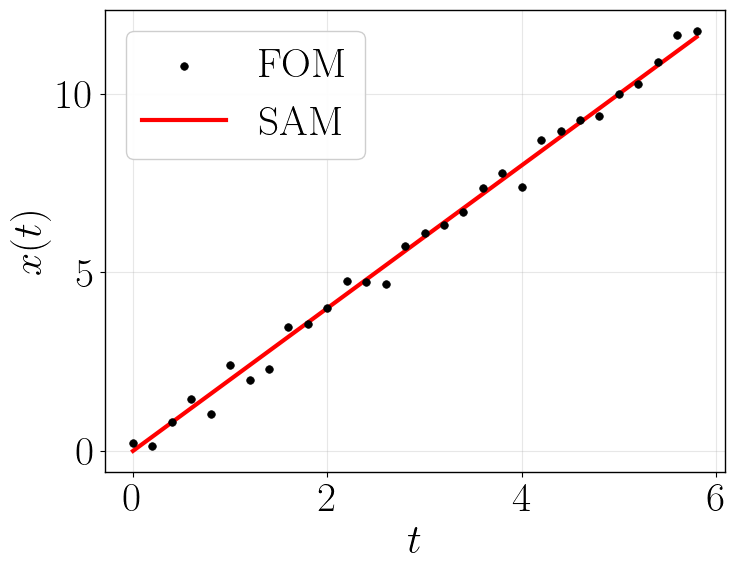

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\prior.pdf


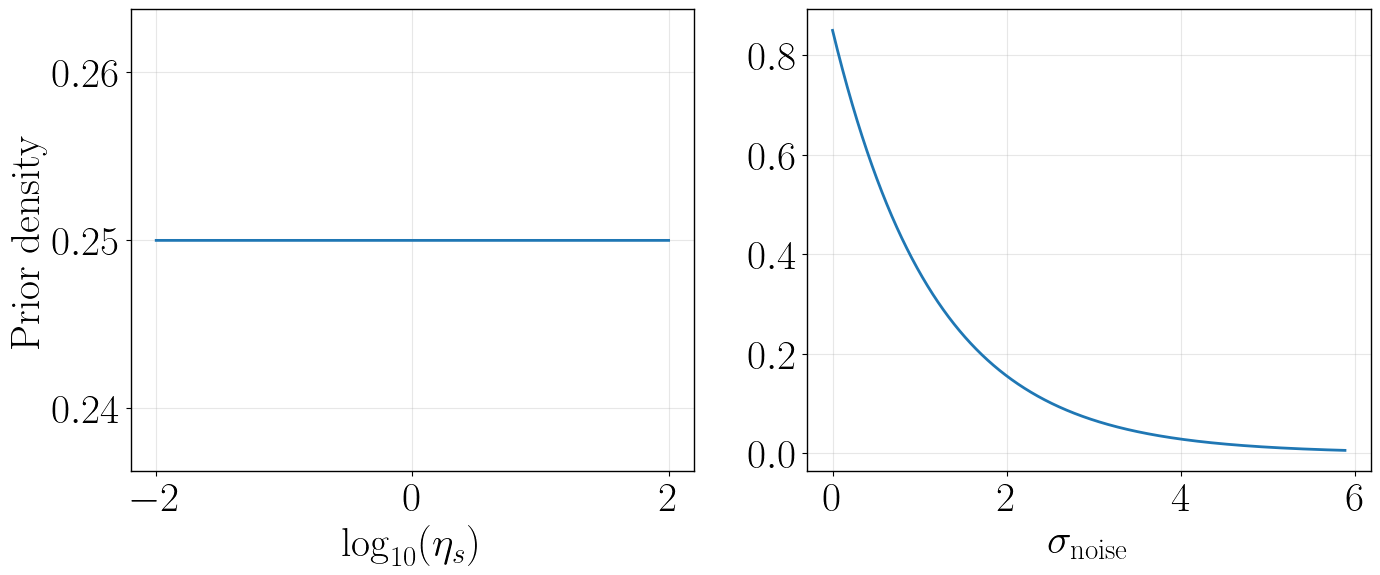


Preparing MCMC: ndim=2, walkers=4, steps=10000, init=kmeans, warmup=True

Initial walkers (physical):
  00: [0.56952627 1.70941958]
  01: [6.15845988 3.67651811]
  02: [12.46878666  0.10171529]
  03: [27.18890265  1.65917253]

Warm-up: 1000 steps x 4 walkers


100%|██████████| 1000/1000 [00:00<00:00, 1423.71it/s]



Walkers after warm-up (physical):
  00: [1.00450778 0.31782145]
  01: [0.97894396 0.23536964]
  02: [0.93767127 0.33395725]
  03: [0.99718072 0.29415948]


100%|██████████| 10000/10000 [00:07<00:00, 1408.15it/s]



MCMC Diagnostics Summary
Chains: 4  |  Samples/chain after burn-in: 7000  |  Total: 28000
----------------------------------------------------------------
Parameter                Mean            Std       Rhat
----------------------------------------------------------------
eta_s              9.9679e-01     7.7979e-03     1.0059
sigma_noise        3.0113e-01     4.1212e-02     1.0051
----------------------------------------------------------------
Mean Rhat                                        1.0055
Std Rhat                                         0.0004

Posterior-predictive adequacy (x, replicated data):
  Nominal central coverage of band:  95.0%
  ----------------------------------------------------------------
  series               cover     RMS z    max|z|    mean z
  dataset[0] x         96.7%      0.93      2.00     -0.07
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\posterior_predictive.pdf


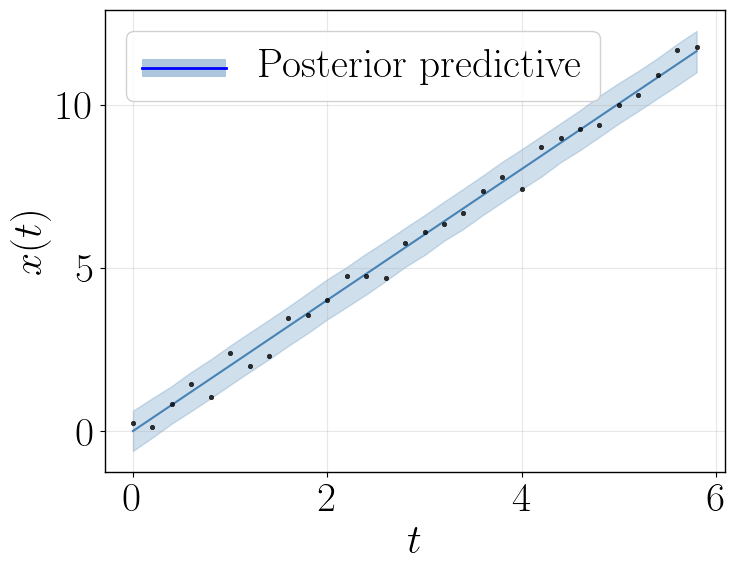

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\corner.pdf


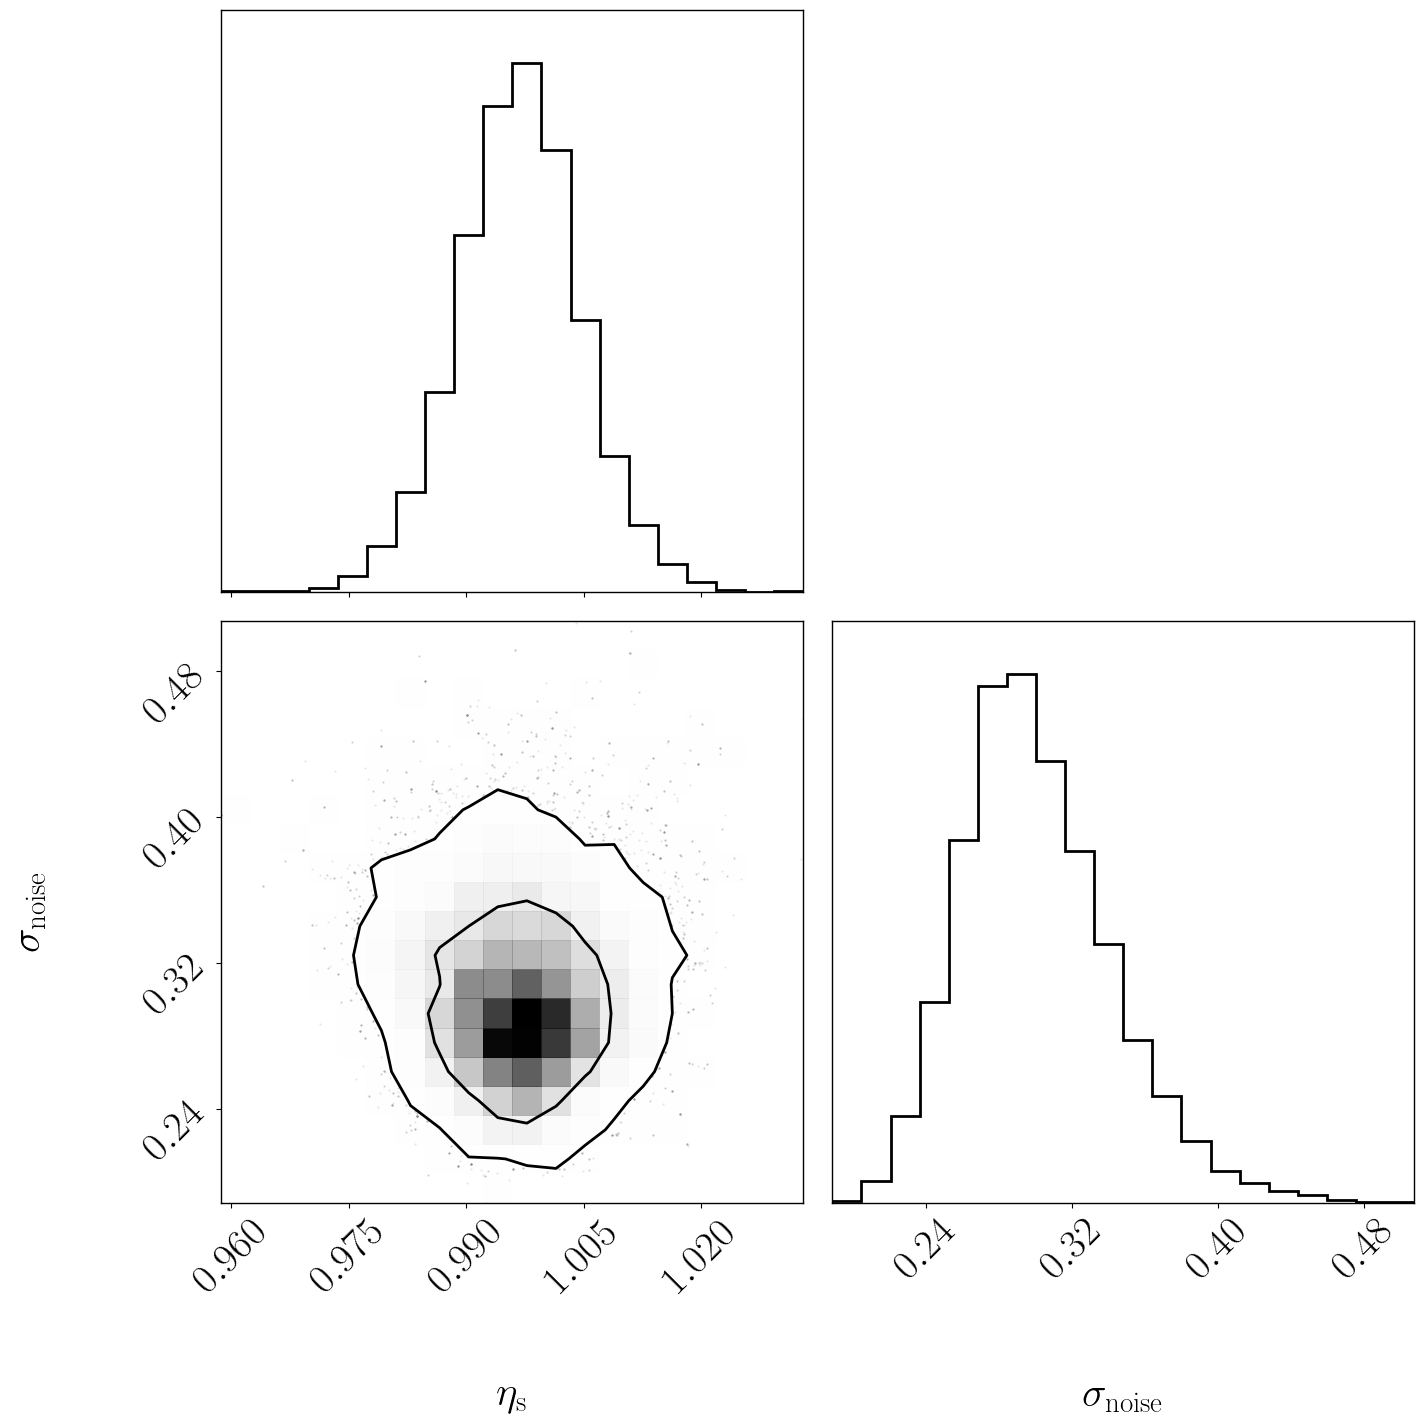

In [ ]:
import sys
import os
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from packages.main import  InferenceProcedure

model = InferenceProcedure(
    force=12*np.pi,
    material_model="newtonian", # "newtonian", "viscoelastic"
    boundary_model="unbounded", # "unbounded", "bounded"
    theta=0, 
    a=1.0,
    sigma_noise_percent= 2.0,
    sigma_bias=None,
    nsteps=10000,
    thin_factor=1)

model.load_data("data/newtonian/unbounded/delta-100-0.txt")
model.plot_data(theta_true=[1])
model.plot_prior()
model.run_mcmc(init_method= "kmeans")
model.plot_results()